# Clustering de Pacientes por Perfil de Síntomas PHQ-9

En este notebook aplicamos aprendizaje **no supervisado** para descubrir subgrupos de pacientes con patrones similares de síntomas depresivos.

La hipótesis clínica es que el MDD no es una enfermedad homogénea: algunos pacientes presentan síntomas predominantemente cognitivos (anhedonia, concentración), otros somáticos (sueño, energía, apetito), y otros afectivos (ánimo deprimido). Identificar estos subtipos puede orientar tratamientos más personalizados.

## Índice
1. [Imports y preparación de datos](#1)
2. [Imports y exploración](#2)
3. [Features del modelo](#3)
4. [Split](#4)
5. [Resultados de regresión](#5)
6. [Scatter plots](#6)
7. [Feature Importance](#7)
8. [Conclusiones](#8)

## 1. Imports y preparación de datos <a id='1'></a>

In [1]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sys.path.append('..')

from src.phq9.data_loader import cargar_datos, preprocesar_features, preparar_clustering
from src.phq9.clustering import elegir_k, aplicar_kmeans, aplicar_umap, aplicar_hdbscan
from src.phq9.clustering import graficar_umap, graficar_heatmap, graficar_boxplots, validar_clusters

FIGURES_DIR = '../results/figures/phq9'
METRICS_DIR = '../results/metrics/phq9'

# cargar y agregar por usuario
df_raw = cargar_datos()
df     = preprocesar_features(df_raw)
X_cluster, user_ids, df_agg = preparar_clustering(df)

print(f'\nPacientes: {len(user_ids)}')
print(f'Features por paciente: {X_cluster.shape[1]}')

c:\Users\basti\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Cargando: C:\Codigos\Samsung Innovation\depresion_mdd\data\raw\PHQ-9\Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv
[INFO] Shape original: (16150, 36)
[INFO] Filas eliminadas sin target: 286
[INFO] Shape tras limpieza: (15864, 18)
[INFO] Features preprocesadas:
  Nulos restantes:
happiness.score    0
phq.day            0
hour               0
period.name        0
sex                0
age                0
dtype: int64
  [WARN] NaN en phq2 imputados con mediana=2.00
  [WARN] NaN en phq3 imputados con mediana=2.00
  [WARN] NaN en phq4 imputados con mediana=3.00
  [WARN] NaN en phq5 imputados con mediana=1.00
  [WARN] NaN en phq6 imputados con mediana=2.00
  [WARN] NaN en phq7 imputados con mediana=2.00
  [WARN] NaN en phq8 imputados con mediana=1.00
  [WARN] NaN en phq9 imputados con mediana=1.00
[INFO] Matriz clustering: (180, 11)
  Features: ['phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'happiness_mean', 'happiness_std']

Pacientes: 180
Feature

### ¿Por qué agregar por `user_id`?

El dataset EMA tiene ~87 observaciones por paciente. Para clustering queremos agrupar **pacientes**, no observaciones individuales. Por eso primero reducimos el dataset de 16,150 filas a 185 filas, una por paciente.

Las features de cada paciente son:
- `phq1`–`phq9`: respuesta a cada ítem del cuestionario (valor fijo, tomado al inicio del estudio)
- `happiness_mean`: media del happiness score durante los 14 días
- `happiness_std`: desviación estándar del happiness score (variabilidad emocional)

Incluir `happiness_std` es relevante porque pacientes con alta variabilidad emocional pueden tener un perfil diferente aunque su PHQ-9 total sea similar.

## 2. Elección del número de clusters (K) <a id='2'></a>

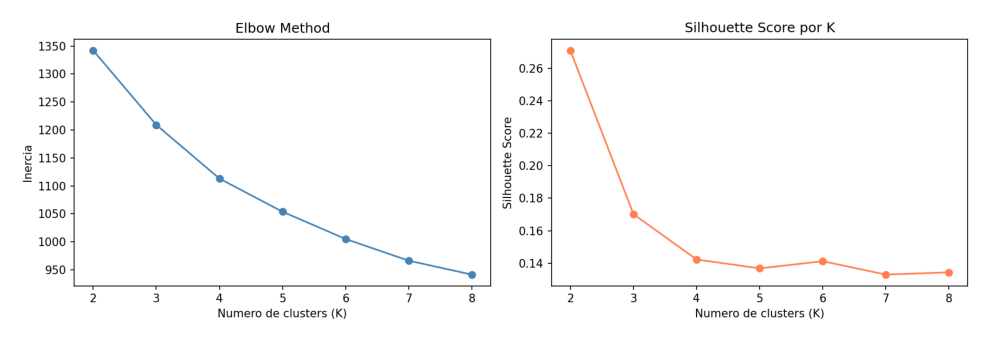

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'clustering_elbow_silhouette.png')))
ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretación:**

- **Elbow method**: la inercia cae fuertemente de K=2 a K=3, luego se aplana. El codo está en K=2.
- **Silhouette score**: máximo en K=2 (0.271), cae a 0.170 en K=3 y sigue bajando. Un silhouette más cercano a 1 indica clusters más compactos y separados.

Ambas métricas convergen en **K=2** como el número óptimo de clusters para este dataset.

## 3. K-Means con K=2 <a id='3'></a>

In [3]:
labels_kmeans = aplicar_kmeans(X_cluster, k=2)

[INFO] K-Means K=2 | Silhouette=0.271


## 4. Reducción UMAP y validación con HDBSCAN <a id='4'></a>

**UMAP** (Uniform Manifold Approximation and Projection) reduce las 11 features a 2 dimensiones para visualización, preservando la estructura de vecindad local del espacio original.

**HDBSCAN** (Hierarchical DBSCAN) es un algoritmo de clustering basado en densidad que no requiere especificar K. Lo aplicamos sobre el embedding UMAP para validar de forma independiente si la estructura de 2 grupos es real.

In [4]:
embedding      = aplicar_umap(X_cluster)
labels_hdbscan = aplicar_hdbscan(embedding)

c:\Users\basti\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] UMAP embedding: (180, 2)
[INFO] HDBSCAN: 5 clusters, 35 outliers


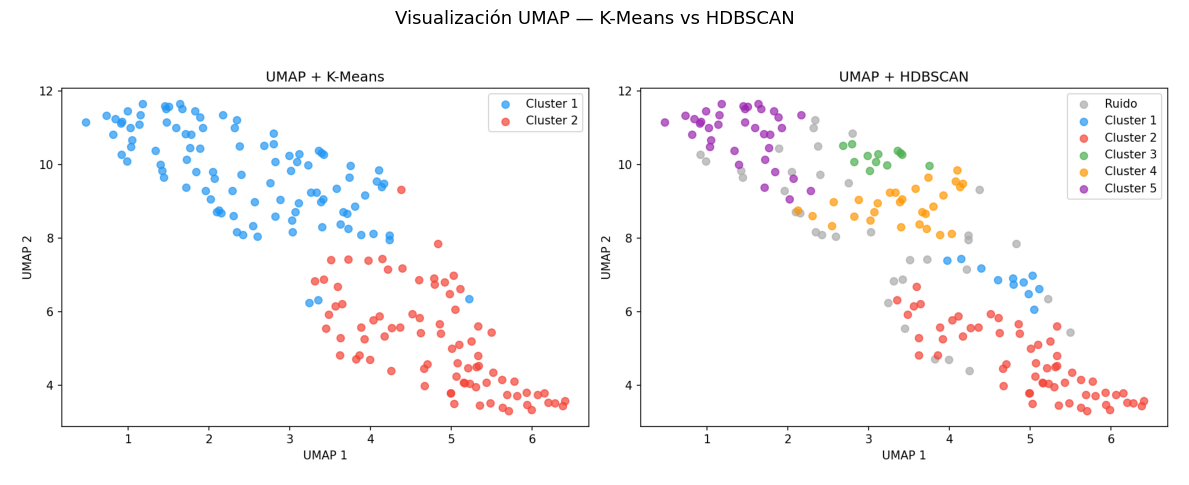

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'clustering_umap.png')))
ax.axis('off')
plt.suptitle('Visualización UMAP — K-Means vs HDBSCAN', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Perfil de síntomas por cluster <a id='5'></a>

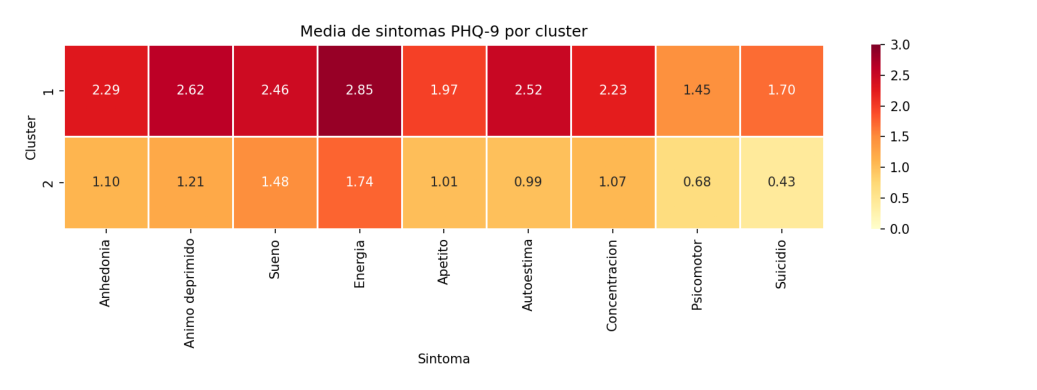

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'clustering_heatmap_sintomas.png')))
ax.axis('off')
plt.tight_layout()
plt.show()

El heatmap muestra la intensidad media (0–3) de cada uno de los 9 síntomas PHQ por cluster. Permite identificar qué síntomas diferencian a los grupos.

## 6. Distribución de PHQ-9 y felicidad por cluster <a id='6'></a>

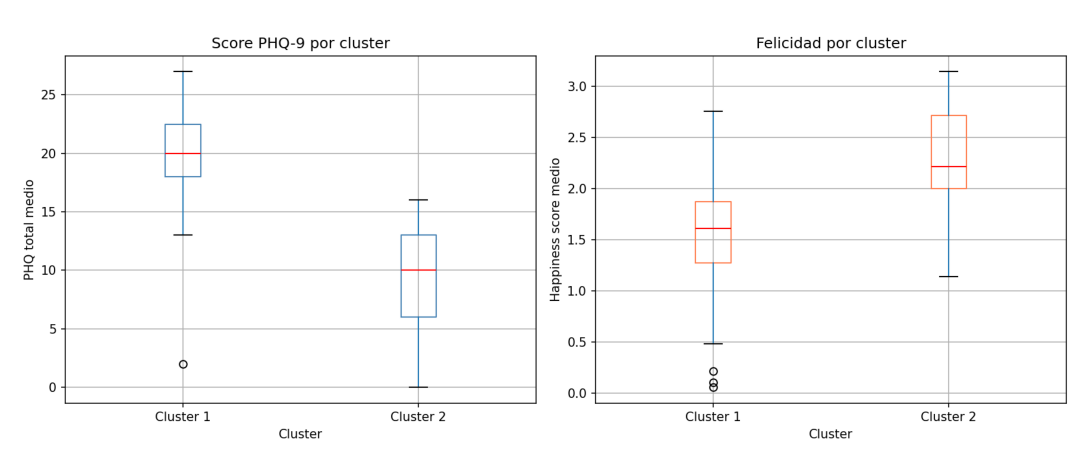

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'clustering_boxplots.png')))
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Validación clínica

In [8]:
# tabla resumen de los clusters
with open(os.path.join(METRICS_DIR, 'clustering_kmeans_resumen.json')) as f:
    resumen = json.load(f)

filas = []
for cluster_id, vals in resumen.items():
    filas.append({
        'Cluster': cluster_id.replace('_', ' ').capitalize(),
        'N pacientes': vals['n'],
        'PHQ-9 medio': vals['phq_total_mean'],
        'Happiness medio': vals['happiness_mean'],
        'Happiness std': vals['happiness_std'],
        'Edad media': vals['age_mean'],
    })

df_resumen = pd.DataFrame(filas).set_index('Cluster')
display(df_resumen.style
        .background_gradient(cmap='RdYlGn_r', subset=['PHQ-9 medio'])
        .background_gradient(cmap='RdYlGn', subset=['Happiness medio'])
        .format('{:.3f}', subset=['PHQ-9 medio', 'Happiness medio', 'Happiness std', 'Edad media']))

,N pacientes,PHQ-9 medio,Happiness medio,Happiness std,Edad media
Cluster,,,,,
Cluster 1,99,19.949,1.532,0.777,27.900
Cluster 2,81,9.543,2.312,0.646,28.600


## 8. Conclusiones

**1. K=2 es el número óptimo de clusters (silhouette=0.271).**  
Con solo 185 pacientes, más de 2 clusters produce grupos demasiado pequeños y mal separados. El silhouette de 0.271 indica separación moderada, los clusters son identificables pero con superposición, lo cual es esperable en datos clínicos con alta variabilidad.

**2. Los dos clusters tienen perfiles clínicamente distinguibles:**

| | Cluster 1 | Cluster 2 |
|---|---|---|
| N | 99 | 81 |
| PHQ-9 medio | 19.95 (depresión severa) | 9.54 (depresión leve-moderada) |
| Happiness | 1.53 (muy bajo) | 2.31 (moderado) |
| Happiness std | 0.78 | 0.65 |

- **Cluster 1**: pacientes con síntomas más intensos en todos los ítems PHQ y menor felicidad reportada. Corresponde al grupo de depresión **severa**.
- **Cluster 2**: pacientes con síntomas más leves y mayor capacidad hedónica residual. Corresponde a depresión **leve a moderada**.

**3. HDBSCAN confirma la estructura de 2 grupos.**  
Aunque HDBSCAN no requiere especificar K, el embedding UMAP revela la misma separación en 2 grupos que K-Means identifica, lo que valida que la estructura no es un artefacto del método.

**4. La variabilidad emocional (happiness_std) es una feature informativa.**  
Pacientes del Cluster 1 tienen mayor variabilidad en felicidad (0.78 vs 0.65), lo que sugiere mayor labilidad emocional en el grupo de depresión severa. Esto es consistente con la literatura sobre regulación emocional en MDD.

**5. Limitación: los clusters reflejan principalmente la severidad, no el subtipo.**  
La separación encontrada es básicamente entre depresión severa y leve-moderada. Para identificar subtipos (ej. melancólico vs atípico) se necesitaría un dataset mayor con más variables clínicas.